# EDA Mac

In [1]:
from IPython.display import SVG, display, HTML
import cairosvg
from IPython.display import Image
import io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

train_df.shape

(50000, 3)

## View Distributions

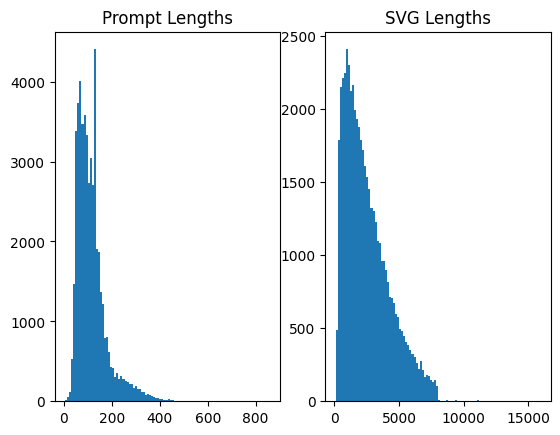

In [3]:
prompt_lengths = train_df['prompt'].apply(lambda x : len(x))
svg_lengths = train_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots(1, 2)
ax[0].hist(prompt_lengths, bins=100)
ax[0].set_title('Prompt Lengths')
ax[1].hist(svg_lengths, bins=100)
ax[1].set_title('SVG Lengths')
plt.show()

In [4]:
ALL_COLORS = ['black', 'white', 'grey', 'gray', 'red', 'blue', 'orange', 'yellow', 'green', 'purple', 'pink']
# COLORS = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
COLORS = ['red', 'blue', 'orange', 'yellow', 'green', 'purple', 'pink']
def get_color_dist(df:pd.DataFrame, text):
    for c in ALL_COLORS:
        # Counts the number of rows that have a certain color
        print(f'{text}: ', c, sum(df['prompt'].apply(lambda x: c in x)))
    
# colors = ['black', 'white', 'grey', 'gray', 'red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
# for c in colors:
#     print('Train DF Prompt: ', c, sum(train_df['prompt'].apply(lambda x: c in x)))
# for c in colors:
#     print('Train DF SVG: ', c, sum(train_df['svg'].apply(lambda x: c in x)))
get_color_dist(train_df, 'train')
get_color_dist(test_df, 'test')

train:  black 27886
train:  white 28165
train:  grey 80
train:  gray 4523
train:  red 8031
train:  blue 6469
train:  orange 1376
train:  yellow 1440
train:  green 1327
train:  purple 687
train:  pink 783
test:  black 531
test:  white 553
test:  grey 1
test:  gray 94
test:  red 155
test:  blue 137
test:  orange 31
test:  yellow 26
test:  green 36
test:  purple 21
test:  pink 18


## Color Tweeking Results

In [5]:
# Original data sample
# old_train_sample = train_df.loc[210, :]
prompt_svg_sample = train_df.iloc[30]
# old_train_sample = train_df.iloc[300]
print(prompt_svg_sample['prompt'],'\n\n', prompt_svg_sample['svg'])


The image shows a black padlock icon on a white background, featuring a rectangular body and a curved shackle with a circular keyhole in the center. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#333333" fill-opacity="1.0"  filling="0" d="M158.126953125 75.18203735351562 L57.69023132324219 75.18203735351562 L57.69023132324219 58.53964614868164 A41.89726638793945 41.89726638793945 0.0 1 1 141.4845733642578 58.53964614868164 A8.3212890625 8.3212890625 0.0 0 0 158.126953125 58.53964614868164 A58.53964614868164 58.53964614868164 0.0 1 0 41.047847747802734 58.53964614868164 L41.047847747802734 75.18203735351562 A24.963672637939453 24.963672637939453 0.0 0 0 16.666603088378906 100.14569854736328 L16.666603088378906 175.03631591796875 A24.963672637939453 24.963672637939453 0.0 0 0 41.63027572631836 200.0 L158.126953125 200.0 A24.963672637939453 24.963672637939453 0.0 0 0 183.09063720703125 175.03631591796875 L183.09063720

A blue square icon with a white curved line resembling a 'U' shape. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#257AE7" fill-opacity="1.0"  filling="0" d="M148.13499450683594 29.412002563476562 L52.85300064086914 29.412002563476562 C43.96799850463867 29.412002563476562 36.57099914550781 36.064998626708984 35.86500549316406 44.6879997253418 L26.527000427246094 158.4290008544922 C25.735000610351562 168.0850067138672 33.56800079345703 176.3470001220703 43.51499938964844 176.3470001220703 L157.47300720214844 176.3470001220703 C167.42100524902344 176.3470001220703 175.26199340820312 168.08200073242188 174.46200561523438 158.4290008544922 L165.1230010986328 44.6879997253418 C164.41799926757812 36.064998626708984 157.02099609375 29.412002563476562 148.13499450683594 29.412002563476562 Z"></path>
<path fill="#5195EC" fill-opacity="1.0"  filling="0" d="M165.1230010986328 44.6879997253418 C164.41799926757812 36.0559997558

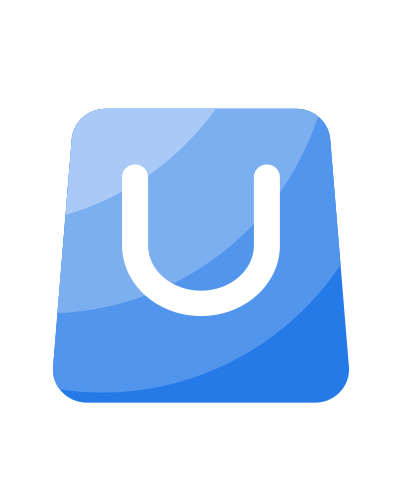

SVG source: 3429 characters
PNG output:  13,158 bytes


In [31]:
# old_train_sample = train_df.iloc[33]
old_train_sample = train_df.sample().iloc[0]

def get_svg_image(prompt_svg_sample:pd.Series):
    print(prompt_svg_sample['prompt'],'\n\n', prompt_svg_sample['svg'])

    # Render SVG to PNG using cairosvg
    png_bytes = cairosvg.svg2png(bytestring=prompt_svg_sample['svg'].encode('utf-8'),
                                output_width=400, output_height=500)

    # Display the rasterized version
    display(Image(data=png_bytes, format='png'))
    print(f"SVG source: {len(prompt_svg_sample['svg'])} characters")
    print(f"PNG output:  {len(png_bytes):,} bytes")
get_svg_image(old_train_sample)

Replace the coloring

#2B7BEE
#5597F4
#7FB5F4
#AECBFB
A blue square icon with a white curved line resembling a 'U' shape. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#2B7BEE" fill-opacity="1.0"  filling="0" d="M148.13499450683594 29.412002563476562 L52.85300064086914 29.412002563476562 C43.96799850463867 29.412002563476562 36.57099914550781 36.064998626708984 35.86500549316406 44.6879997253418 L26.527000427246094 158.4290008544922 C25.735000610351562 168.0850067138672 33.56800079345703 176.3470001220703 43.51499938964844 176.3470001220703 L157.47300720214844 176.3470001220703 C167.42100524902344 176.3470001220703 175.26199340820312 168.08200073242188 174.46200561523438 158.4290008544922 L165.1230010986328 44.6879997253418 C164.41799926757812 36.064998626708984 157.02099609375 29.412002563476562 148.13499450683594 29.412002563476562 Z"></path>
<path fill="#5597F4" fill-opacity="1.0"  filling="0" d="M165.1230010986328 44.6879997253418 C

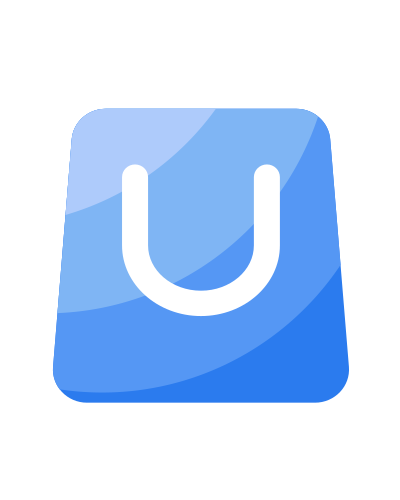

SVG source: 3429 characters
PNG output:  13,156 bytes


In [32]:
import re

# BO_WG_color_mapping = {
#     'black' : ['orange', ['"#000000"', '"0"'], '"#FF6A00"'],
#     'white' : ['green', ['"#FFFFFF"', '"#FFFFFF"'], '"#00FF00"'],
# }
# def replace_color(str:str, color_map):
#     # Simple replace does not work across colors, too many different formats, and such. 
#     for k in list(color_map.keys()):
#         # Replace Prompt
#         str = str.replace(k, color_map[k][0])
#         # Replace hex RGB
#         str = str.replace(color_map[k][1][0], color_map[k][2])
#         str = str.replace(color_map[k][1][1], color_map[k][2])
#     return str

def color_tweek(str:str):
    """
    We want to increase the number of colored examples, so we want to slightly adjust the colored values only
    This function only increments the color values by a random amount evenly
    """
    def adjust_color(match:re.Match):
        # noise = np.random.randint(0, 100)
        # noise = np.random.randint(0, 10)
        noise = 10
        color = match.group(0)
        if color.lower() in ['#000000', '#ffffff']:
            return color
        r = int(color[1:3], 16)
        g = int(color[3:5], 16)
        b = int(color[5:7], 16)
        # Slightly adjust by adding noise to each component
        # r = min(255, r + noise)
        # g = min(255, g + noise)
        # b = min(255, b + noise)
        r = min(255, r + np.random.randint(0, noise))
        g = min(255, g + np.random.randint(0, noise))
        b = min(255, b + np.random.randint(0, noise))
        print(f'#{r:02x}{g:02x}{b:02x}'.upper())
        return f'#{r:02x}{g:02x}{b:02x}'.upper()

    pattern = r'#[0-9a-fA-F]{6}'
    str = re.sub(pattern, adjust_color, str)
    return str

# new_train_sample = old_train_sample.apply(replace_color, args=(BO_WG_color_mapping,))
new_train_sample = old_train_sample.apply(color_tweek)

get_svg_image(new_train_sample)


## Tweek Colors Across dataframe

In [8]:
# # Replaced colors data
# def replace_BW_colors(df:pd.DataFrame, color_map):
#     new_df = df.copy()
#     new_df = new_df[new_df['prompt'].str.contains(r'(black)|(white)', case=False)]
#     new_df['prompt'] = new_df['prompt'].apply(replace_color, args=(color_map,))
#     new_df.reset_index(inplace=True, drop=True)
#     return new_df

COLORS_REGEX = f'({COLORS[0]})'
for c in COLORS[1:]:
    COLORS_REGEX += f'|({c})'

def df_tweek_colors(df:pd.DataFrame, color_list:list):
    """
    Returns a new dataframe, of rows that contain prompts with colors.
    Prompts with both BW and colors are included
    The color values in the svg have been tweeked by color_tweek.
    """
    new_df = df.copy()

    colors_regex = f'({color_list[0]})'
    for c in color_list[1:]:
        colors_regex += f'|({c})'
    # print(COLORS_REGEX) # Debug

    new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]
    new_df['prompt'] = new_df['prompt'].apply(color_tweek)
    new_df.reset_index(inplace=True, drop=True)
    return new_df

In [9]:
# color_train_df = replace_BW_colors(train_df, BO_WG_color_mapping)
# color_train_df

color_train_df = df_tweek_colors(train_df, COLORS)
color_train_df

/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/1400647033.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]


,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."
2,0e629ca90f9d3271dd224e2d6bd45b6e,A black-and-white icon depicting a secured win...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,4368171726accb70f7e5e2dcf7cc1c00,"A simple, green line drawing of a potted cactu...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,b4b9c86ee637c6d837a28340f3aafdf7,The image features a blue circular outline con...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
...,...,...,...
17221,thesantatitan_deepseek-svg-dataset_0000241,Generate svg code for an image that looks like...,"<svg width=""400"" height=""400"" viewBox=""0 0 400..."
17222,05c038b09bdf2b503b79a49d0d1ec031,A black and white illustration of a taxi with ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
17223,77626302ad9e12887faac630f7c1b47d,The image features a light gray rectangle with...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
17224,d05c8a1ca1a2470557a08aeefe77e144,"A red mug with steam rising from it, symbolizi...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


### Checking Color Distributions

In [10]:
get_color_dist(color_train_df, 'color dist')

color dist:  black 6448
color dist:  white 8563
color dist:  grey 20
color dist:  gray 1358
color dist:  red 8031
color dist:  blue 6469
color dist:  orange 1376
color dist:  yellow 1440
color dist:  green 1327
color dist:  purple 687
color dist:  pink 783


In [11]:
# No black or white in the prompt
get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(r'(black)|(white)')], 'No B or W')

# Not Colors in the prompt
get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)], 'No Color')
color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)].iloc[0, 1]
# The regex expression not perfect, need escape char for 'red\W'.

No B or W:  black 0
No B or W:  white 0
No B or W:  grey 16
No B or W:  gray 645
No B or W:  red 1565
No B or W:  blue 3809
No B or W:  orange 777
No B or W:  yellow 870
No B or W:  green 814
No B or W:  purple 436
No B or W:  pink 492
No Color:  black 27
No Color:  white 26
No Color:  grey 1
No Color:  gray 1
No Color:  red 0
No Color:  blue 0
No Color:  orange 0
No Color:  yellow 0
No Color:  green 0
No Color:  purple 0
No Color:  pink 0


/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/3644818561.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(r'(black)|(white)')], 'No B or W')
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/3644818561.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  get_color_dist(color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)], 'No Color')
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/3644818561.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  color_train_df[~color_train_df['prompt'].str.contains(COLORS_REGEX)].iloc[0, 1]


'The image features a black circular background with a white Reddit alien mascot icon in the center, including its antenna and smiling face.'

The image features a stylized blue human figure icon centered within a black rectangular frame. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#474747" fill-opacity="1.0"  filling="0" d="M175.5400390625 77.6900405883789 A6.0 6.0 0.0 0 1 169.5400390625 71.6900405883789 L169.5400390625 38.55000305175781 A9.56992244720459 9.56992244720459 0.0 0 0 160.0 29.0 L126.58008575439453 29.0 A6.0 6.0 0.0 0 1 126.58008575439453 17.0 L160.0 17.0 A21.590038299560547 21.590038299560547 0.0 0 1 181.56991577148438 38.559959411621094 L181.56991577148438 71.6900405883789 A6.0 6.0 0.0 0 1 175.5400390625 77.6900405883789 Z M159.85000610351562 180.30996704101562 L126.7099609375 180.30996704101562 A6.0 6.0 0.0 1 1 126.7099609375 168.30996704101562 L159.85000610351562 168.30996704101562 A9.56992244720459 9.56992244720459 0.0 0 0 169.40997314453125 158.75 L169.40997314453125 125.3599624633789 A6.0 6.0 0.0 1 1 181.4099578857422 125.35996246337

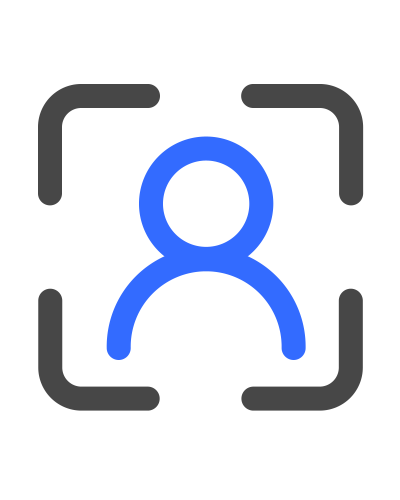

SVG source: 2604 characters
PNG output:  14,165 bytes


In [12]:
img_sample = color_train_df.iloc[13, :]

get_svg_image(img_sample)

## Creating Final Appended Color Dataset

In [13]:
get_color_dist(train_df, 'train')
# Colors are not evenly distributed
# red, blue, > orange, yellow, green, > purple, pink

train:  black 27886
train:  white 28165
train:  grey 80
train:  gray 4523
train:  red 8031
train:  blue 6469
train:  orange 1376
train:  yellow 1440
train:  green 1327
train:  purple 687
train:  pink 783


In [14]:
# all_color_mappers = [
#     {
#         'black' : ['orange', '#000000', '#FF6A00'],
#         'white' : ['green', '#FFFFFF', "#00FF00"],
#     },
#     {
#         'black' : ['yellow', '#000000', "#FFEE00"],
#         'white' : ['purple', '#FFFFFF', "#950095"],
#     },
#     {
#         'black' : ['blue', '#000000', "#0000FF"],
#         'white' : ['gray', '#FFFFFF', "#888888"],
#     },
#     {
#         'black' : ['grey', '#000000', "#888888"],
#         'white' : ['pink', '#FFFFFF', "#FF00FF"],
#     }
# ]

# final_colors_df = []
# for i in range(len(all_color_mappers)):
#     final_colors_df.append(replace_BW_colors(train_df, all_color_mappers[i]))
# final_colors_df = pd.concat(final_colors_df)
# final_colors_df.shape, train_df.shape, get_color_dist(final_colors_df, 'final_colors')


final_colors_df = []
# Colors are not evenly distributed
# red, blue, > orange, yellow, green, > purple, pink

for i in range(1):
    # red
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[1])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

for i in range(1):
    # blue
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[2])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

for i in range(10):
    # Orange Green Yellow
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[2:5])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

for i in range(20):
    # Purple and Pink
    tweeked_colors_df = df_tweek_colors(train_df, COLORS[5:])
    # Get only colored prompts
    tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
    final_colors_df.append(tweeked_colors_df)

final_colors_df = pd.concat(final_colors_df)
final_colors_df.reset_index(drop=True, inplace=True)
final_colors_df.shape, train_df.shape, get_color_dist(final_colors_df, 'final_colors')


/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/1400647033.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/3122676788.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tweeked_colors_df = tweeked_colors_df[~tweeked_colors_df['prompt'].str.contains(r'(black)|(white)')]
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/1400647033.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  new_df = new_df[new_df['prompt'].str.contains(colors_regex, case=False)]
/var/folders/22/543r7zlx5431mj53f8jx1nsr0000gn/T/ipykernel_3396/3122676788.py:42: UserWarning: This pa

final_colors:  black 0
final_colors:  white 0
final_colors:  grey 156
final_colors:  gray 7658
final_colors:  red 8390
final_colors:  blue 16028
final_colors:  orange 10384
final_colors:  yellow 12520
final_colors:  green 10568
final_colors:  purple 10502
final_colors:  pink 11724


((73612, 3), (50000, 3), None)

## Combining with Original Train, Control how many

In [15]:
# Sub Sample Distribution
final_colors_df.sample(25000).shape, get_color_dist(final_colors_df.sample(25000), 'final sample')

final sample:  black 0
final sample:  white 0
final sample:  grey 50
final sample:  gray 2545
final sample:  red 2866
final sample:  blue 5376
final sample:  orange 3497
final sample:  yellow 4321
final sample:  green 3553
final sample:  purple 3650
final sample:  pink 4018


((25000, 3), None)

In [16]:
# Colored distribution
final_combined_df = pd.concat([train_df, final_colors_df.sample(73612)])
get_color_dist(final_combined_df, 'final_combined_df'), final_combined_df.shape

final_combined_df:  black 27886
final_combined_df:  white 28165
final_combined_df:  grey 236
final_combined_df:  gray 12181
final_combined_df:  red 16421
final_combined_df:  blue 22497
final_combined_df:  orange 11760
final_combined_df:  yellow 13960
final_combined_df:  green 11895
final_combined_df:  purple 11189
final_combined_df:  pink 12507


(None, (123612, 3))

The image shows a stylized, simplified representation of a pink shirt with a reddish-brown collar and cuffs, featuring three yellow buttons arranged vertically on the left side. 

 <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#A54137" fill-opacity="1.0"  filling="0" d="M131.48126220703125 6.484375 C124.83436584472656 16.824996948242188 114.34062957763672 21.993751525878906 100.0 21.993751525878906 C85.65937042236328 21.993751525878906 73.3687515258789 16.743751525878906 63.131248474121094 6.25 L60.006248474121094 40.91875076293945 L134.515625 40.91875076293945 L131.48126220703125 6.4812469482421875 L131.48126220703125 6.484375 Z"></path>
<path fill="#DF9A95" fill-opacity="1.0"  filling="0" d="M149.8000030517578 193.76251220703125 A3.125 3.125 0.0 0 0 153.11248779296875 196.68124389648438 L193.45623779296875 193.96249389648438 A3.125 3.125 0.0 0 0 196.38125610351562 190.64999389648438 L196.35000610351562 190.365631103

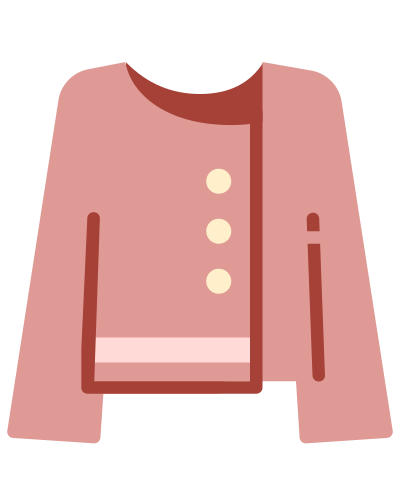

SVG source: 3510 characters
PNG output:  14,945 bytes


In [17]:
# Spam run to see samples
get_svg_image(final_colors_df.sample().iloc[0])

In [18]:
# Original training dataset stats
get_color_dist(train_df, 'train DF'), train_df.shape

train DF:  black 27886
train DF:  white 28165
train DF:  grey 80
train DF:  gray 4523
train DF:  red 8031
train DF:  blue 6469
train DF:  orange 1376
train DF:  yellow 1440
train DF:  green 1327
train DF:  purple 687
train DF:  pink 783


(None, (50000, 3))

In [19]:
final_combined_df.sample(100000).shape, get_color_dist(final_combined_df.sample(100000), 'final_combined_df')

final_combined_df:  black 22673
final_combined_df:  white 22875
final_combined_df:  grey 195
final_combined_df:  gray 9837
final_combined_df:  red 13272
final_combined_df:  blue 18116
final_combined_df:  orange 9458
final_combined_df:  yellow 11286
final_combined_df:  green 9646
final_combined_df:  purple 9024
final_combined_df:  pink 10119


((100000, 3), None)

In [20]:
# final_combined_df.sample(100000).to_csv('./dataset/final_combined_df_100000.csv')

In [21]:
final_combined_df.sample().iloc[0]['svg']

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#8d9ca8" fill-opacity="1.0"  filling="0" d="M115.36699676513672 75.1500015258789 L115.36699676513672 62.11800003051758 L84.63099670410156 62.11800003051758 L84.63099670410156 75.1500015258789 C84.63099670410156 76.77999877929688 83.50399780273438 78.19300079345703 81.91400146484375 78.55400085449219 C68.68199920654297 81.56099700927734 59.29100036621094 93.32499694824219 59.29100036621094 106.8949966430664 L59.29100036621094 111.0250015258789 L60.893001556396484 111.67900085449219 L60.893001556396484 164.26199340820312 L59.29100036621094 164.8000030517578 L59.29100036621094 192.97900390625 C59.29100036621094 196.85699462890625 62.435001373291016 200.0 66.31300354003906 200.0 L133.68499755859375 200.0 C137.56300354003906 200.0 140.70599365234375 196.8560028076172 140.70599365234375 192.97900390625 L140.70599365234375 164.8000030517578 L139.50100708007812 163.8249969482422 

## Limiting Token Lengths, don't finetune on partial svg lengths

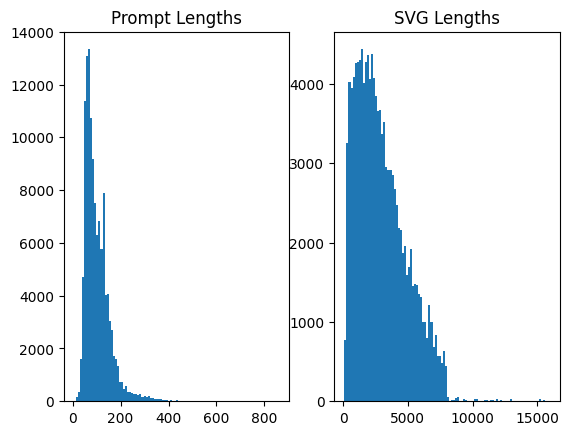

In [22]:
# Original Distribution
prompt_lengths = final_combined_df['prompt'].apply(lambda x : len(x))
svg_lengths = final_combined_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots(1, 2)
ax[0].hist(prompt_lengths, bins=100)
ax[0].set_title('Prompt Lengths')
ax[1].hist(svg_lengths, bins=100)
ax[1].set_title('SVG Lengths')
plt.show()

In [23]:
token_len_final_combined_df = final_combined_df[final_combined_df['svg'].apply(lambda x : len(x) < 4700)]
token_len_final_combined_df = token_len_final_combined_df[token_len_final_combined_df['prompt'].apply(lambda x : len(x) <= 200)]
token_len_final_combined_df
# Final total input to model should be less than 5000, > 4700 + 200 = 4900
# margin for special tokens and other prompt set ups, 100 chars

,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,919a7da8bd44dc7781dbe87383a268cc,The image displays a black icon with a photo-l...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
4,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like...,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24..."
5,d342c3ca-4c5a-492f-9a93-1604bcb9a4b2,An arrow pointing right emerges from a line lo...,"<svg fill=""none"" height=""128"" viewBox=""0 0 24 ..."
...,...,...,...
11243,236b6fd6-9f99-4d67-9576-7b308c6268a0,A clock icon showing把手 at 1 of 2 and 3.,"<svg fill=""none"" height=""128"" viewBox=""0 0 24 ..."
63768,23d629c8a0f3ea808295423018960f0b,A geometric logo featuring overlapping triangl...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2381,825efa75868f657ad50d21db074d1252,The image consists of three identical green sw...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
48622,b6909c1a8642d7976444805e2b18f71d,"The image features a stylized, flat design of ...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


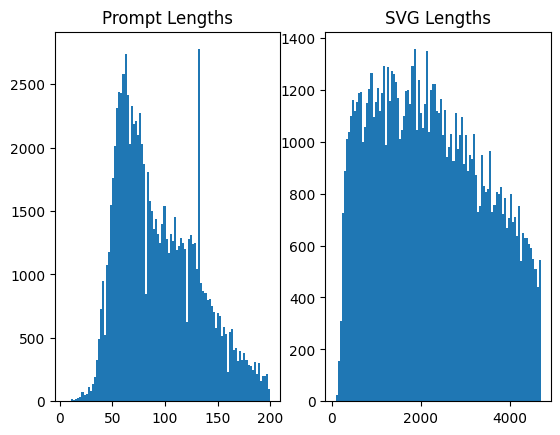

In [24]:
# New Distribution
prompt_lengths = token_len_final_combined_df['prompt'].apply(lambda x : len(x))
svg_lengths = token_len_final_combined_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots(1, 2)
ax[0].hist(prompt_lengths, bins=100)
ax[0].set_title('Prompt Lengths')
ax[1].hist(svg_lengths, bins=100)
ax[1].set_title('SVG Lengths')
plt.show()

In [25]:
get_color_dist(token_len_final_combined_df, 'token_len_final_combined_df')

token_len_final_combined_df:  black 21692
token_len_final_combined_df:  white 21750
token_len_final_combined_df:  grey 199
token_len_final_combined_df:  gray 10095
token_len_final_combined_df:  red 12449
token_len_final_combined_df:  blue 17594
token_len_final_combined_df:  orange 8382
token_len_final_combined_df:  yellow 9764
token_len_final_combined_df:  green 8081
token_len_final_combined_df:  purple 8336
token_len_final_combined_df:  pink 8019


In [26]:
token_len_final_combined_df.to_csv('./dataset/final_df.csv')

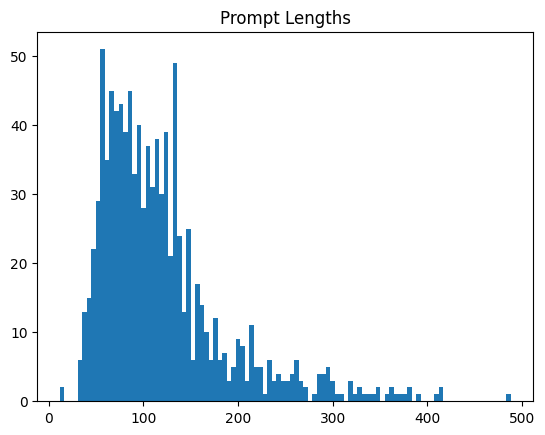

In [28]:
# Original TESET Distribution
prompt_lengths = test_df['prompt'].apply(lambda x : len(x))
# svg_lengths = test_df['svg'].apply(lambda x : len(x))
fig, ax = plt.subplots()
ax.hist(prompt_lengths, bins=100)
ax.set_title('Prompt Lengths')
# ax[1].hist(svg_lengths, bins=100)
# ax[1].set_title('SVG Lengths')
plt.show()

In [29]:
(test_df['prompt'].apply(lambda x: len(x) > 200)).sum(), (test_df['prompt'].apply(lambda x: len(x) <= 200)).sum()

(np.int64(114), np.int64(886))